In [34]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
from torchvision import datasets
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
transform = transforms.Compose([
transforms.Resize((128,128)),
transforms.ToTensor()
])

data = datasets.ImageFolder(root = r"C:\Users\badis\Desktop\cat vs dog classification\archive\dogcat\train",transform = transform)
generator1 = torch.Generator().manual_seed(11)
dataTrain,dataTest = random_split(data,[0.8,0.2],generator =generator1)


#class DataTest(Dataset):
    #def __init__(self,folderpath,transform):
    #    self.folder_path = folderpath
    #    self.file_list = os.listdir(self.folder_path)
    #    self.transform = transform

    #def __len__(self):
    #    return len(self.file_list)
#
    #def __getitem__(self,index):
   #     filename = self.file_list[index] 
   #     full_path = os.path.join(self.folder_path, filename)
   #     img = Image.open(full_path)
   # #    img = img.convert('RGB')
    #    return self.transform(img)

# dataTest = DataTest(r"C:\Users\badis\Desktop\cat vs dog classification\archive\dogcat\test1\test1", transform)





In [102]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.ConvLayer = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3)
        self.MaxPool = nn.MaxPool2d(kernel_size = 3)
        self.FirstLayer = nn.Linear(56448,784)
        self.SecondLayer = nn.Linear(784,1)

    def forward(self,data):
        relu = nn.ReLU()
        first = self.ConvLayer(data)
        first = relu(first)
        second = self.MaxPool(first)
        second = torch.flatten(second, start_dim = 1, end_dim = 3)
        third = self.FirstLayer(second)
        third = relu(third)
        fourth = self.SecondLayer(third)
        sigmoid = nn.Sigmoid()
        return sigmoid(fourth)
        



In [104]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # allowing gpu to do training
Loss = nn.BCELoss()
NeuralNetwork = Model().to(device)
optimizer = torch.optim.SGD(NeuralNetwork.parameters(), lr = 0.1)


DataTrainOBJ = DataLoader(dataTrain, batch_size = 16, shuffle = True)

for i in range(50):
    for batch in DataTrainOBJ:
        image, label = batch
        image = image.to(device)
        label = label.to(device)
        prediction = NeuralNetwork(image)
        prediction = prediction.squeeze(dim = 1)
        label = label.float()
        prediction = prediction.float()
        results = Loss(prediction, label)
        results.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(i)    
        



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


prediction is dog
0.17999999225139618


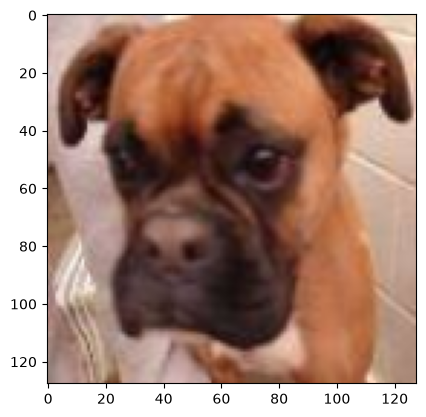

In [ ]:
DataTest = DataLoader(dataTest, batch_size = 16, shuffle = True)
total = 0
i = 0
for batchs in DataTest:
    images, labels = batchs
    images = images.to(device)
    labels = labels.to(device)
    prediction = NeuralNetwork(images)
    prediction = prediction.squeeze(dim = 1)
    prediction = (prediction > 0.5).float()
    ans = (prediction == labels)
    total += ans.sum()
    IMG = images[15].cpu()
    IMG = IMG.permute(1,2,0)
    IMG = IMG.numpy()
    plt.imshow(IMG)
    if labels[15] == 0:
        print(" prediction is cat")
    else:
        print("prediction is dog")   
    break     
    
   

#accuracy = total / len(dataTest) * 100
#accuracy = accuracy.item()

#print(accuracy)